### OpenVINO: Vehicle detection + color classification

### Import libraries


In [1]:
import logging as log
import os
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov
import bm_utils as utils

warnings.filterwarnings("ignore")


### Install packages

In [2]:
# %pip install -q openvino pandas opencv-python matplotlib gradio

### Initialize OpenVINO
#### Check for available devices in the system


In [3]:
core = ov.Core()
available_devices = core.available_devices
print(available_devices)


['CPU', 'GPU', 'NPU']


#### Check for devices properties


In [4]:
utils.print_device_details(core)


Device full name:  Intel(R) Core(TM) Ultra 7 258V
Supported formats:  ['BF16', 'FP32', 'FP16', 'INT8', 'BIN', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 8)
-------------------------
Device full name:  Intel(R) Arc(TM) 140V GPU (16GB) (iGPU)
Supported formats:  ['FP32', 'BIN', 'FP16', 'INT8', 'GPU_HW_MATMUL', 'GPU_USM_MEMORY', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 2)
-------------------------
Device full name:  Intel(R) AI Boost
Supported formats:  ['FP16', 'INT8', 'EXPORT_IMPORT']
Range for multiple streams:  (1, 4)
-------------------------


### Load and compile models (detection + classification)

Pick a precision folder that exists under `models/`.


In [5]:
precision = "INT8"
models_root = "models"
det_xml, cls_xml = utils.model_xml_paths(models_root, precision)

detection_device = "GPU"
classification_device = "CPU"

detection_model = core.read_model(str(det_xml))
classification_model = core.read_model(str(cls_xml))

compiled_detection = core.compile_model(detection_model, detection_device)
compiled_classification = core.compile_model(classification_model, classification_device)

detection_label = utils.load_labels(det_xml.parent)
detection_label = detection_label[0] if detection_label else "CAR"
classification_labels = utils.load_labels(cls_xml.parent)

# Minimum confidence (0–1) for keeping a detection box; matches ``bm_utils.postprocess_detection`` default.
CONFIDENCE_THRESHOLD = utils.DEFAULT_DETECTION_CONFIDENCE_THRESHOLD


### Load an image


In [6]:
image_path = os.path.join("media", "sample_image-1.jpg")
image = cv2.imread(image_path)

input_tensor, height, width = utils.resize_image(image, compiled_detection)


### Inference — detection


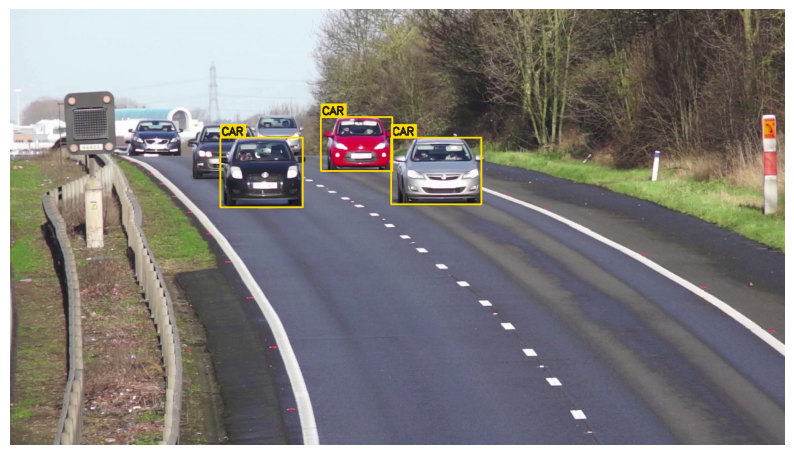

In [7]:
detection_output = compiled_detection([input_tensor])
ih, iw = utils.detection_input_hw(compiled_detection)
boxes, scores = utils.postprocess_detection(
    detection_output, height, width, iw, ih, thresh=CONFIDENCE_THRESHOLD
)

plt.figure(figsize=(10, 6))
final_image = utils.draw(image, boxes)
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


### Inference — detection + classification


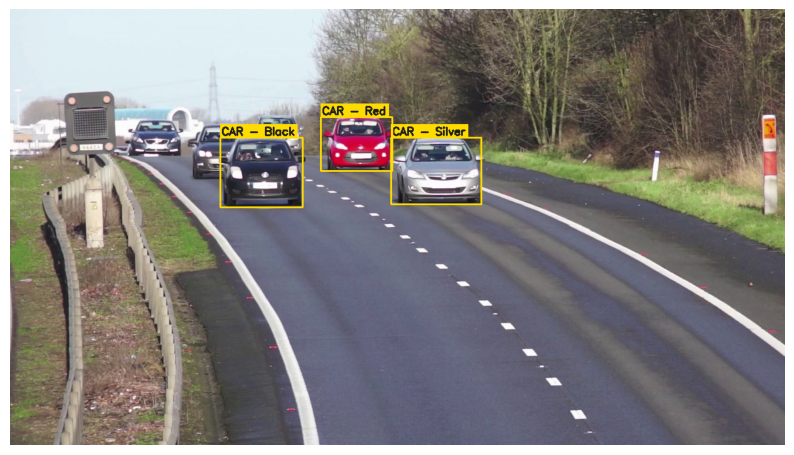

In [8]:
color_names, classification_time_ms = utils.classify_crops_with_labels(
    compiled_classification,
    image,
    boxes,
    classification_labels,
    detection_label=detection_label,
)

plt.figure(figsize=(10, 6))
final_image = utils.draw(image, boxes, labels=color_names)
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


### Benchmark (detection model)

Mean latency over repeated runs and approximate **inferences per second** on the **detection** model (same input tensor).


In [9]:
mean_lat_ms = utils.benchmark_latency_ms(compiled_detection, input_tensor, num_iter=50)
ips, n = utils.benchmark_throughput_ips(compiled_detection, input_tensor, duration_sec=2.0)
print(f"Detection mean latency (50 runs): {mean_lat_ms:.3f} ms")
print(
    f"Detection throughput (~2 s window): {ips:.1f} inferences/s ({n} runs)"
)


Detection mean latency (50 runs): 14.521 ms
Detection throughput (~2 s window): 70.0 inferences/s (140 runs)


### End-to-end pipeline


In [10]:
detection_ms, classification_ms, num_boxes = utils.run_pipeline_latency_ms(
    compiled_detection, compiled_classification, image, thresh=CONFIDENCE_THRESHOLD
)
print(
    f"Detection: {detection_ms:.2f} ms | Classification (all crops): {classification_ms:.2f} ms | "
    f"boxes: {num_boxes} | confidence threshold: {CONFIDENCE_THRESHOLD}"
)


Detection: 15.26 ms | Classification (all crops): 6.99 ms | boxes: 3 | confidence threshold: 0.225


### Optional: `benchmark_app` + Gradio (like *Inference with OpenVINO_Original*)

Uses **`bm_utils.py`** + **`app_gradio.build_gr_blocks`** (detection IR only: `models/<precision>/Detection/model.xml`).

Requires **`benchmark_app`** on your PATH (OpenVINO development tools). Run **one** of the cells below at a time (each opens a browser tab).

To see the exact `benchmark_app` command in logs: Jupyter **View → Show Log Console** (set level to Info), same as the original notebook.


In [11]:
# %pip install -q pandas gradio matplotlib

from app_gradio import build_gr_blocks

# If your IRs live elsewhere, set the folder that contains FP32/FP16/INT8:
utils.set_models_root("models")

throughput_demo = build_gr_blocks(available_devices, goal="Throughput")
throughput_demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [12]:
from app_gradio import build_gr_blocks

utils.set_models_root("models")

latency_demo = build_gr_blocks(available_devices, goal="Latency")
latency_demo.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


### Gradio UI (optional)

Uses **`app_gradio.py`**. From this folder:

```bash
python app_gradio.py
```

Or launch from the notebook:


In [13]:
from app_gradio import create_demo

demo = create_demo()
demo.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
